In [1]:
!pip install xgboost shap rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 31.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from rapidfuzz import process, fuzz
import shap
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import string


In [3]:
yield_df = pd.read_csv("/content/drive/MyDrive/krishi sakhi/datasets /combined yeild production.csv", low_memory=False)

weather_pre = pd.read_csv("/content/drive/MyDrive/krishi sakhi/datasets /weather_2023_2025.csv", low_memory=False)
weather_post = pd.read_csv("/content/drive/MyDrive/krishi sakhi/datasets /weather_pre_2023.csv", low_memory=False)

weather_df = pd.concat([weather_pre, weather_post], ignore_index=True)

In [4]:
yield_df = yield_df[yield_df['area_production'].isin(['Area','Production'])]

area = yield_df[yield_df['area_production']=='Area'].copy()
prod = yield_df[yield_df['area_production']=='Production'].copy()

area['value'] = pd.to_numeric(area['value'], errors='coerce')
prod['value'] = pd.to_numeric(prod['value'], errors='coerce')

merged_yield = pd.merge(area, prod,
                        on=['year','district','mandal','crop_name'],
                        suffixes=('_area','_prod'))

merged_yield = merged_yield.dropna(subset=['value_area','value_prod'])
merged_yield['yield'] = merged_yield['value_prod'] / merged_yield['value_area']


In [5]:
weather_df.columns = weather_df.columns.str.lower().str.strip()

print("Weather columns detected:")
print(weather_df.columns)

Weather columns detected:
Index(['district', 'mandal', 'date', 'rain (mm)', 'min temp (°c)',
       'max temp (°c)', 'min humidity (%)', 'max humidity (%)',
       'min wind speed (kmph)', 'max wind speed (kmph)', 'district', 'mandal',
       'date', 'rainfall (mm)', 'temp_min (⁰c)', 'temp_max (⁰c)',
       'humidity_min (%)', 'humidity_max (%)', 'wind_speed_min (kmph)',
       'wind_speed_max (kmph)'],
      dtype='object')


In [6]:
weather_df.rename(columns={
    'rainfall (mm)': 'rainfall',
    'temp_min (⁰c)': 'min_temp',
    'temp_max (⁰c)': 'max_temp',
    'humidity_min (%)': 'min_humidity',
    'humidity_max (%)': 'max_humidity',
    'wind_speed_min (kmph)': 'min_wind',
    'wind_speed_max (kmph)': 'max_wind'
}, inplace=True)


In [7]:
num_cols = ['rainfall','min_temp','max_temp','min_humidity','max_humidity','min_wind','max_wind']
for c in num_cols:
    weather_df[c] = pd.to_numeric(weather_df[c], errors='coerce')

In [8]:
print(weather_df.columns)
weather_df = weather_df.loc[:, ~weather_df.columns.duplicated()]

Index(['district', 'mandal', 'date', 'rain (mm)', 'min temp (°c)',
       'max temp (°c)', 'min humidity (%)', 'max humidity (%)',
       'min wind speed (kmph)', 'max wind speed (kmph)', 'district', 'mandal',
       'date', 'rainfall', 'min_temp', 'max_temp', 'min_humidity',
       'max_humidity', 'min_wind', 'max_wind'],
      dtype='object')


In [9]:
weather_df['temperature'] = (weather_df['min_temp'] + weather_df['max_temp']) / 2
weather_df['humidity'] = (weather_df['min_humidity'] + weather_df['max_humidity']) / 2
weather_df['wind_speed'] = (weather_df['min_wind'] + weather_df['max_wind']) / 2
weather_df['date'] = pd.to_datetime(weather_df['date'], errors='coerce')
weather_df['year'] = weather_df['date'].dt.year
weather_df['month'] = weather_df['date'].dt.month


/tmp/ipython-input-198/2708579336.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weather_df['date'] = pd.to_datetime(weather_df['date'], errors='coerce')


In [10]:
weather_climate = weather_df.groupby('district').agg({
    'rainfall':'mean',
    'temperature':'mean',
    'humidity':'mean',
    'wind_speed':'mean'
}).reset_index()

monsoon = weather_df[weather_df['month'].between(6,9)]
monsoon_rain = monsoon.groupby('district')['rainfall'].mean().reset_index(name='monsoon_rainfall')

weather_climate = weather_climate.merge(monsoon_rain, on='district', how='left')
weather_climate['monsoon_rainfall'] = weather_climate['monsoon_rainfall'].fillna(0)


In [11]:
def clean_text(col):
    return (
        col.astype(str)
        .str.lower()
        .str.strip()
        .str.replace(r'[^a-z0-9 ]', '', regex=True)
    )

merged_yield['district'] = clean_text(merged_yield['district'])
weather_climate['district'] = clean_text(weather_climate['district'])
yield_districts = merged_yield['district'].unique()
weather_districts = weather_climate['district'].unique()

mapping = {}
for yd in yield_districts:
    match = process.extractOne(yd, weather_districts, scorer=fuzz.token_sort_ratio)
    if match and match[1] > 80:
        mapping[yd] = match[0]

merged_yield['district_mapped'] = merged_yield['district'].map(mapping)
merged_yield = merged_yield.dropna(subset=['district_mapped'])


In [12]:
data = pd.merge(
    merged_yield,
    weather_climate,
    left_on='district_mapped',
    right_on='district',
    how='inner'
)

print("Rows after merge:", data.shape)


Rows after merge: (18783, 24)


In [13]:
data['location_id'] = data['district_mapped'] + "_" + data['mandal'].astype(str)

le_loc = LabelEncoder()
data['location_enc'] = le_loc.fit_transform(data['location_id'])


In [14]:
data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna(subset=['yield']).reset_index(drop=True)

idx = data.groupby(['year','location_id'])['yield'].idxmax()
best_crop = data.loc[idx.dropna().astype(int)].copy()


/tmp/ipython-input-198/3703648435.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace([np.inf, -np.inf], np.nan)


In [15]:
for col in ['rainfall','monsoon_rainfall','temperature','humidity','wind_speed','yield']:
    upper = best_crop[col].quantile(0.99)
    lower = best_crop[col].quantile(0.01)
    best_crop[col] = best_crop[col].clip(lower, upper)



📊 Class distribution after cleaning:
crop_name_clean
watermelon       139
tomato            40
cucumber          30
capsicum          27
banana            19
brinjal           10
polyhouse_veg      7
Name: count, dtype: int64

📊 CV Accuracy: [0.96363636 0.90909091 0.92592593 0.94444444 0.98148148]
Mean: 0.944915824915825 Std: 0.025813829112018256

🎯 Test Accuracy: 0.9636363636363636
               precision    recall  f1-score   support

       banana       1.00      0.75      0.86         4
      brinjal       1.00      1.00      1.00         2
     capsicum       1.00      1.00      1.00         6
     cucumber       0.86      1.00      0.92         6
polyhouse_veg       0.00      0.00      0.00         1
       tomato       0.89      1.00      0.94         8
   watermelon       1.00      1.00      1.00        28

     accuracy                           0.96        55
    macro avg       0.82      0.82      0.82        55
 weighted avg       0.95      0.96      0.95        55


🎯 To

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Figure size 1050x900 with 0 Axes>

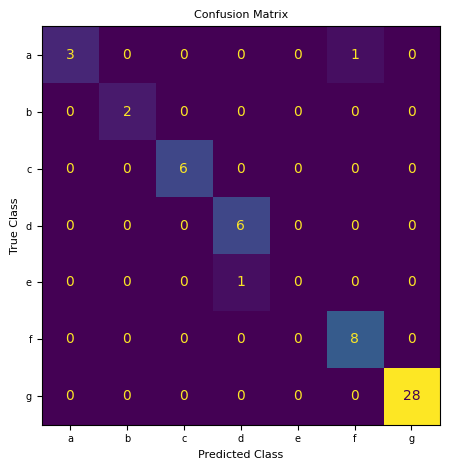


📘 Class Legend:
  Label           Crop
0     a         banana
1     b        brinjal
2     c       capsicum
3     d       cucumber
4     e  polyhouse_veg
5     f         tomato
6     g     watermelon


In [16]:
def normalize_crop(name):
    name = str(name).lower().strip()

    # collapse grouped labels
    if name.startswith("others"):
        return "others"

    mapping = {
        "water melon": "watermelon",
        "capsicum(coloured,green)": "capsicum",
        "brinjal/vankaya": "brinjal",
        "european cucumber": "cucumber",
        "total polyhouse vegetables": "polyhouse_veg"
    }

    for k, v in mapping.items():
        if k in name:
            return v

    return name


# =========================================================
# 2️⃣ PREP DATA
# =========================================================
features = [
    'location_enc',
    'rainfall',
    'monsoon_rainfall',
    'temperature',
    'humidity',
    'wind_speed',
    'yield'
]

data_model = best_crop.copy()

# 🔹 Clean labels
data_model["crop_name_clean"] = data_model["crop_name"].apply(normalize_crop)

# 🔹 Remove generic class (optional but recommended)
data_model = data_model[data_model["crop_name_clean"] != "others"]

# 🔹 Remove rare crops
min_samples = 5
valid_classes = data_model["crop_name_clean"].value_counts()
valid_classes = valid_classes[valid_classes >= min_samples].index

data_model = data_model[data_model["crop_name_clean"].isin(valid_classes)]

print("\n📊 Class distribution after cleaning:")
print(data_model["crop_name_clean"].value_counts())


# =========================================================
# 3️⃣ ENCODE TARGET
# =========================================================
label_encoder = LabelEncoder()
data_model["crop_label"] = label_encoder.fit_transform(data_model["crop_name_clean"])

X = data_model[features]
y = data_model["crop_label"]


# =========================================================
# 4️⃣ TRAIN TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# =========================================================
# 5️⃣ TRAIN MODEL
# =========================================================
crop_model = XGBClassifier(
    n_estimators=400,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42
)

crop_model.fit(X_train, y_train)


# =========================================================
# 6️⃣ CROSS VALIDATION
# =========================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    crop_model,
    X, y,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

print("\n📊 CV Accuracy:", cv_scores)
print("Mean:", cv_scores.mean(), "Std:", cv_scores.std())


# =========================================================
# 7️⃣ TEST EVALUATION
# =========================================================
y_pred = crop_model.predict(X_test)

print("\n🎯 Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


# =========================================================
# 8️⃣ TOP-3 ACCURACY
# =========================================================
probs = crop_model.predict_proba(X_test)
top_k = 3
topk_idx = np.argsort(probs, axis=1)[:, -top_k:][:, ::-1]

top3_acc = np.mean([y_test.iloc[i] in topk_idx[i] for i in range(len(y_test))])
print("\n🎯 Top-3 Accuracy:", round(top3_acc, 4))

print("\n🔎 Sample Predictions")
for i in range(min(5, len(X_test))):
    print(f"\nSample {i+1}")
    for rank, idx in enumerate(topk_idx[i], 1):
        crop = label_encoder.inverse_transform([idx])[0]
        prob = probs[i][idx]
        print(f"{rank}. {crop} — {prob:.3f}")


# =========================================================
# 9️⃣ CONFUSION MATRIX (IEEE STYLE)
# =========================================================
cm = confusion_matrix(y_test, y_pred)
letters = list(string.ascii_lowercase[:len(label_encoder.classes_)])

plt.figure(figsize=(3.5, 3.0), dpi=300)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=letters
)

disp.plot(colorbar=False)
plt.title("Confusion Matrix", fontsize=8)
plt.xlabel("Predicted Class", fontsize=8)
plt.ylabel("True Class", fontsize=8)
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()

plt.savefig("confusion_matrix_ieee.pdf", bbox_inches="tight")
plt.show()


# =========================================================
# 🔟 CLASS LEGEND
# =========================================================
legend_df = pd.DataFrame({
    "Label": letters,
    "Crop": label_encoder.classes_
})

print("\n📘 Class Legend:")
print(legend_df)

In [20]:

season_model = XGBClassifier().fit(X_train, y_train)  # replace with real model
X_season = X_test
y_season = y_test

In [21]:
# =========================
# CROP BUSINESS METRICS (CLEAN)
# =========================

top1_advisory_acc = float(accuracy_score(y_test, y_pred) * 100)
top3_planning_cov = float(top3_acc * 100)
season_preds = season_model.predict(X_season)
season_consistency = float(np.mean(season_preds == y_season) * 100)

print("\n🌾 CROP BUSINESS METRICS")
print(f"Top-1 Advisory Accuracy: {top1_advisory_acc:.2f}%")
print(f"Top-3 Planning Coverage: {top3_planning_cov:.2f}%")
print(f"Season Consistency: {season_consistency:.2f}%")


🌾 CROP BUSINESS METRICS
Top-1 Advisory Accuracy: 96.36%
Top-3 Planning Coverage: 100.00%
Season Consistency: 96.36%


In [18]:
# =========================
# CROP ADVISORY OUTPUTS
# =========================

num_samples = 5

print("\n🌾  CROP ADVISORY OUTPUTS")

for i in range(num_samples):
    true_crop = label_encoder.inverse_transform([y_test.iloc[i]])[0]
    top1_idx = y_pred[i]
    top1_crop = label_encoder.inverse_transform([top1_idx])[0]

    print(f"\nSample {i+1}")
    print(f"Actual Crop: {true_crop}")
    print(f"Recommended Crop (Top-1): {top1_crop}")

    print("Top-3 Recommendations:")
    for rank, idx in enumerate(topk_idx[i], 1):
        crop_name = label_encoder.inverse_transform([idx])[0]
        prob = probs[i][idx]
        print(f"  {rank}. {crop_name} — {prob:.3f}")


🌾  CROP ADVISORY OUTPUTS

Sample 1
Actual Crop: cucumber
Recommended Crop (Top-1): cucumber
Top-3 Recommendations:
  1. cucumber — 0.944
  2. capsicum — 0.028
  3. watermelon — 0.010

Sample 2
Actual Crop: tomato
Recommended Crop (Top-1): tomato
Top-3 Recommendations:
  1. tomato — 0.564
  2. brinjal — 0.365
  3. banana — 0.028

Sample 3
Actual Crop: watermelon
Recommended Crop (Top-1): watermelon
Top-3 Recommendations:
  1. watermelon — 0.995
  2. capsicum — 0.001
  3. cucumber — 0.001

Sample 4
Actual Crop: capsicum
Recommended Crop (Top-1): capsicum
Top-3 Recommendations:
  1. capsicum — 0.969
  2. watermelon — 0.014
  3. cucumber — 0.005

Sample 5
Actual Crop: brinjal
Recommended Crop (Top-1): brinjal
Top-3 Recommendations:
  1. brinjal — 0.883
  2. tomato — 0.073
  3. banana — 0.016


In [ ]:
# =========================================================
# SAVE ARTIFACTS
# =========================================================
import joblib, json

crop_model.save_model("/content/crop_model.json")
joblib.dump(label_encoder, "/content/crop_label_encoder.pkl")

with open("/content/features.json", "w") as f:
    json.dump(features, f)

print("\n✅ Pipeline completed successfully")


✅ Pipeline completed successfully
